# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis'

# Section 1

Section 1 content

In [4]:
# Import the necessary libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

In [5]:
# Load the cleaned dataset in
df = pd.read_csv('Dataset/CleanData/cleaned_fraud_dataset.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 50000 rows, 20 columns


,Transaction_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,hour,day_of_week
0,TXN_33553,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0,19,Monday
1,TXN_9427,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1,4,Wednesday
2,TXN_199,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1,15,Tuesday
3,TXN_12447,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1,0,Thursday
4,TXN_39489,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1,23,Saturday


---

# Overview
I will look at the dataset before testing any hypothesis, including how balanced the fraud vs genuine transactions are

### Class counts

In [6]:
df['Fraud_Label'].value_counts()

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

### Class count as %

In [7]:
df['Fraud_Label'].value_counts(normalize=True) * 100

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64

The dataset contains 33,933 genuine transactions and 16,067 fraudulent transactions meaning roughly 32% of all transactions are fraudulent. This is fairly balanced compared to real-world fraud rates which are usually much lower but it still me gives a meaningful minority class to test against.

# H1 - Recent failed transactions and fraud

Are customers with more failed transactions in the past week more likely to commit fraud?

H0: there is no significant difference in Failed_Transaction_Count_7d between fraudulent and genuine transactions.

H1: Fraudulent Transactions have a significantly higher Failed_Transaction_Count_7d than genuine transactions.


First, a look at the mean, median, and standard deviation of Failed_Transaction_Count_7d for fraudulent vs genuine transactions. This shows whether fraudulent transactions tend to have more failed attempts on average, and whether that pattern is consistent or spread out across the group.


In [8]:
df.groupby('Fraud_Label')['Failed_Transaction_Count_7d'].describe()

,count,mean,std,min,25%,50%,75%,max
Fraud_Label,,,,,,,,
0,33933.0,1.507353,1.121198,0.0,1.0,2.0,3.0,3.0
1,16067.0,3.051472,1.396953,0.0,2.0,4.0,4.0,4.0


In [9]:
df.groupby('Fraud_Label')['Failed_Transaction_Count_7d'].median()

Fraud_Label
0    2.0
1    4.0
Name: Failed_Transaction_Count_7d, dtype: float64

This suggests fraudulent transactions tend to have roughly double the number of failed attempts compared to genuine ones (mean of 3.05 vs 1.51) with the median showing the same pattern (4 vs 2) meaning this difference isn't just being driven by a few extreme cases.

I have done an independent t-test to check whether this difference is statistically significant, or could just be due to random chance.

In [10]:
fraud = df[df['Fraud_Label']==1]['Failed_Transaction_Count_7d']
non_fraud = df[df['Fraud_Label']==0]['Failed_Transaction_Count_7d']

t_stat, p_value = stats.ttest_ind(fraud, non_fraud, equal_var=False)
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value}")

t-statistic: 122.65
p-value: 0.0


The p-value is far below 0.05, meaning this result is statistically significant.

I will create a Boxplot to visualise the difference between the two groups.

In [11]:
sns.boxplot(x='Fraud_Label', y='Failed_Transaction_Count_7d', data=df)
plt.title('Failed Transactions (7d) by Fraud Status')
plt.show()

<Figure size 640x480 with 1 Axes>

Result: Rejected H0 (p < 0.001)

Fraudulent transactions have a noticeably higher average number of failed transactions in the past 7 days (mean 3.05, median 4) compared to genuine transactions (mean 1.51, median 2). This difference is statistically significant. This suggests that repeated failed attempts are a early warning sign of fraud.

# H2 - Risk score and Fraud

Transactions with a higher risk score are more likely to be fraudulent.

H0: There is no significant difference in Risk_Score between fraudulent and genuine transactions.

H1: Fraudulent transactions have a significantly higher Risk_Score than genuine transactions.

I will look at the mean, median, and standard deviation of Risk_Score for fraudulent vs genuine transactions.

In [12]:
df.groupby('Fraud_Label')['Risk_Score'].agg(['mean', 'median', 'std'])

,mean,median,std
Fraud_Label,,,
0,0.425158,0.4263,0.243874
1,0.662904,0.8069,0.306187


This suggests fraudulent transactions have a noticeably higher risk score on average (mean 0.66 vs 0.43), with the median showing an even larger gap (0.81 vs 0.43) — meaning fraud cases are more consistently pushed toward the higher end of the risk score range, not just pulled up by a few extreme cases. The higher standard deviation for fraud (0.31 vs 0.24) also shows more spread in risk scores among fraud cases.

Before running a t-test, I need to check whether Risk_Score is normally distributed for both groups, since a t-test assumes roughly normal data. I'll check this using a normality test and a histogram/box plot for each group.

In [13]:
fraud = df[df['Fraud_Label']==1]['Risk_Score']
non_fraud = df[df['Fraud_Label']==0]['Risk_Score']

pg.normality(data=df, dv='Risk_Score', group='Fraud_Label', alpha=0.05)

/Users/nav/Desktop/Fraud-Analysis/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33933.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nav/Desktop/Fraud-Analysis/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16067.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Fraud_Label,,,
0,0.956364,1.104931e-69,False
1,0.863391,7.165616e-79,False


I am going to visualise Risk_Score for each group histograms to check the shape of the distribution for fraud and genuine transactions, and a box plot to compare them side by side. This helps confirm whether the data actually looks normally distributed (backing up the normality test above) and makes the difference between the two groups easier to see at a glance than the raw numbers alone.

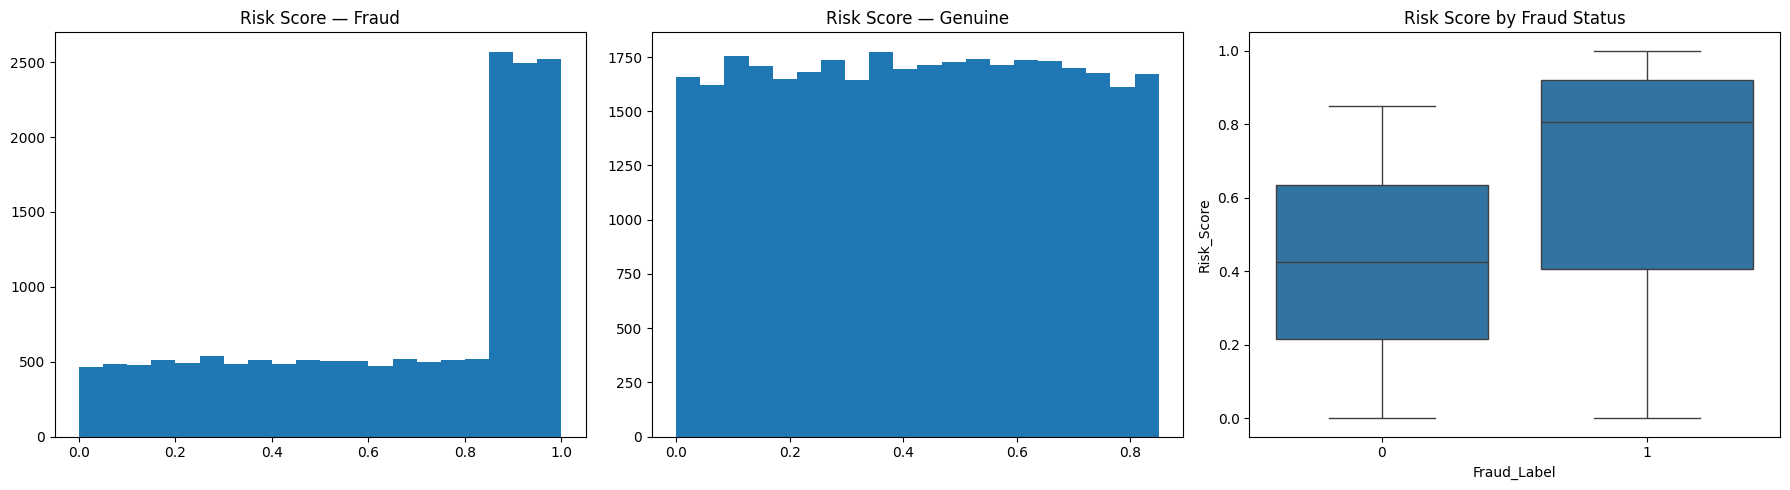

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(fraud, bins=20)
axes[0].set_title('Risk Score — Fraud')

axes[1].hist(non_fraud, bins=20)
axes[1].set_title('Risk Score — Genuine')

sns.boxplot(x='Fraud_Label', y='Risk_Score', data=df, ax=axes[2])
axes[2].set_title('Risk Score by Fraud Status')

plt.tight_layout()
plt.show()

I am doing the t-test to check whether the difference in Risk_Score between the two groups is statistically significant

In [15]:
pg.ttest(fraud, non_fraud)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,86.309389,26054.356737,two-sided,0.0,"[0.23, 0.24]",0.895474,1.0,inf


Now am I am going pull the p-value from the test result to check it against the 0.05 significance threshold.

In [16]:
pg.ttest(fraud, non_fraud).loc['T_test', 'p_val']

0.0

In [17]:
print(f"{pg.ttest(fraud, non_fraud).loc['T_test', 'p_val']:.2e}")
# Used AI to see if I could get it to print the actual value

0.00e+00


Result: Rejected H0 (p < 0.001)

Summary: Fraudulent transactions have a noticeably higher risk score on average (mean 0.66 vs 0.43) than genuine transactions, with an even larger gap in the median (0.81 vs 0.43). This difference is statistically significant, confirming that the system-generated risk score is a genuinely useful signal for identifying fraud. This supports that flagging transactions with a high risk score for closer review and pairing it with Failed_Transaction_Count_7d could make an even stronger combined signal

# H4 — Transaction type and fraud

H4: Certain transaction types (ATM, Online, Bank Transfer, POS) are more commonly associated with fraud.


In [18]:
df['Transaction_Type'].value_counts()

Transaction_Type
POS               12549
Online            12546
ATM Withdrawal    12453
Bank Transfer     12452
Name: count, dtype: int64

I am going to make a bar plot to investigate transaction types across different fraud levels.

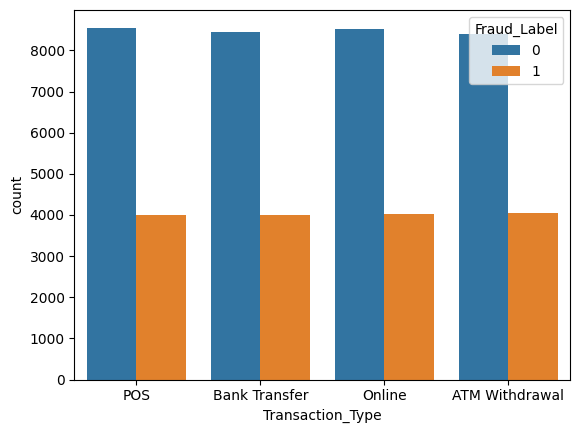

In [19]:
sns.countplot(x='Transaction_Type', hue='Fraud_Label', data=df)
plt.show()

The bar plot shows me that the proportion of fraud is similar across all four transaction types with no Transaction_Type stands out as noticeably riskier than the others.

I am going to use pg.chi2_independence() to do the Chi-Square Test. The arguments we use are data, x and y as the variables for the chi-squared test. y is the target variable Fraud_Label analysed across the feature Transaction_Type.

In [20]:
expected, observed, stats = pg.chi2_independence(data=df, x='Transaction_Type', y='Fraud_Label')

The test summary (stats) has the result of the Pearson Chi-Square test.

In [21]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,1.252930,3.0,0.740340,0.005006,0.134208
1,cressie-read,0.666667,1.252745,3.0,0.740384,0.005005,0.134194
2,log-likelihood,0.000000,1.252380,3.0,0.740471,0.005005,0.134167
3,freeman-tukey,-0.500000,1.252111,3.0,0.740535,0.005004,0.134147
4,mod-log-likelihood,-1.000000,1.251847,3.0,0.740598,0.005004,0.134127
5,neyman,-2.000000,1.251330,3.0,0.740721,0.005003,0.134089


To get the p-value from the Pearson test. I will query from stats where test == 'pearson' and grab the p-value.

In [22]:
stats.query("test == 'pearson'")['pval']

0    0.74034
Name: pval, dtype: float64

Consider our significance level alpha = 0.05.


Since the p-value (0.740) is greater than alpha. This means that we accept the null hypothesis.
This means there is not a significant association between Transaction_Type and Fraud_Label.

Result: Failed to reject H0 (p = 0.740)

Summary: There's no difference in fraud rate across transaction types — ATM, Bank Transfer, Online, and POS all show a very similar proportion of fraudulent transactions. This suggests transaction type alone isn't a useful signal for flagging fraud.

# H5 — Location and fraud

H5: Certain locations have a higher incidence of fraud compared to others.

In [23]:
df['Location'].value_counts()

Location
Tokyo       10208
Mumbai       9994
London       9945
Sydney       9938
New York     9915
Name: count, dtype: int64

I am going to make a bar plot to investigate fraud levels across different locations.

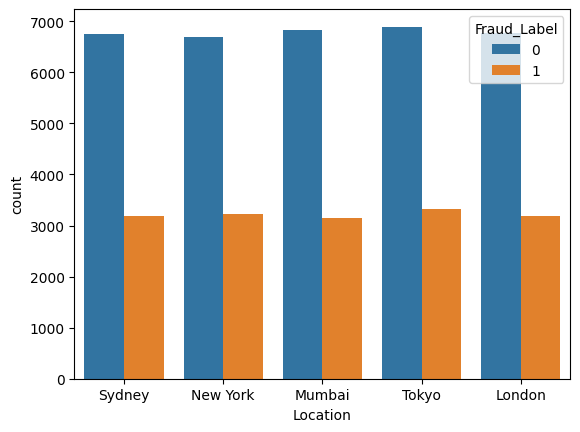

In [24]:
sns.countplot(x='Location', hue='Fraud_Label', data=df)
plt.show()

The bar plot shows that the proportion of fraud is similar across all five locations and there is no single city standing out as noticeably riskier than the others.

Again, I am going to use pg.chi2_independence() to do the Chi-Square Test. y is the target variable Fraud_Label analysed across the feature Location.

In [25]:
expected, observed, stats = pg.chi2_independence(data=df, x='Location', y='Fraud_Label')

The test summary (stats) has the result of the Pearson Chi-Square test.

In [26]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,2.618518,4.0,0.623546,0.007237,0.215873
1,cressie-read,0.666667,2.619289,4.0,0.623410,0.007238,0.215929
2,log-likelihood,0.000000,2.620855,4.0,0.623133,0.007240,0.216044
3,freeman-tukey,-0.500000,2.622049,4.0,0.622922,0.007242,0.216132
4,mod-log-likelihood,-1.000000,2.623261,4.0,0.622708,0.007243,0.216221
5,neyman,-2.000000,2.625738,4.0,0.622271,0.007247,0.216403


To get the p-value from the Pearson test. I will query from stats where test == 'pearson' and grab the p-value.

In [27]:
stats.query("test == 'pearson'")['pval']

0    0.623546
Name: pval, dtype: float64

Consider our significance level alpha = 0.05.


Since the p-value (0.623) is greater than alpha. This means that we accept the null hypothesis.
This means there is not a significant association between Location and Fraud_Label.

Result: Failed to reject H0 (p = 0.623)

Summary: There's no difference in fraud rate across Loactions- London, Mumbai, New York, Sydney and Tokyo all show a very similar proportion of fraudulent transactions. This suggests Location alone isn't a useful signal for flagging fraud.

# H6 — Time patterns and fraud

H6: Fraud is more likely to occur at certain times of the day, on certain days of the week, or on weekends.


I will look at the mead and standard deviation of hour for fraudulent vs genuine transactions.

In [30]:
df.groupby('Fraud_Label')['hour'].agg(['mean', 'std'])

,mean,std
Fraud_Label,,
0,11.488728,6.91198
1,11.574781,6.88192


This shows fraudulent and genuine transactions occur at very similar times on average.

I will run an independent t-test to check whether this small difference in average hour is statistically significant.

In [36]:
fraud_hour = df[df['Fraud_Label']==1]['hour']
non_fraud_hour = df[df['Fraud_Label']==0]['hour']

pg.ttest(fraud_hour, non_fraud_hour)



,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,1.303884,31658.968962,two-sided,0.192283,"[-0.04, 0.22]",0.012467,0.25578,0.025


In [35]:
pg.ttest(fraud_hour, non_fraud_hour).loc['T_test', 'p_val'] # pull the p-value from the t-test results

0.19228259170456558

Now  I will check Is_Weekend. Since this is a category (weekend/weekday) compared against another category (fraud/genuine), a chi-square test is the appropriate choice here.

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [29]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)